<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1TRNaCfYstvcIQqoUSdukYQGF6LuyL7Tv" width=600 height=320/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. Автоэнкодеры


# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import gdown
%matplotlib inline

In [2]:
# Download some attributes

!gdown --id 1utdTz3TY2LyqoRHzZJVVeiku44pacQ0Y

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1utdTz3TY2LyqoRHzZJVVeiku44pacQ0Y
To: /content/lfw_attributes.txt
100% 14.9M/14.9M [00:00<00:00, 69.3MB/s]


In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Remove the corrupted file
!rm -f /content/lfw-dataset.zip
# Re-download the dataset
!kaggle datasets download -d jessicali9530/lfw-dataset -p /content


Dataset URL: https://www.kaggle.com/datasets/jessicali9530/lfw-dataset
License(s): other


In [5]:
import zipfile
import os

zip_path = "/content/lfw-dataset.zip"
extract_dir = "/content/lfw_dataset"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction successful!")
except zipfile.BadZipFile as e:
    print(f"Error: {e}")


Extraction successful!


In [6]:
def fetch_dataset(attrs_name = "lfw_attributes.txt",
                      images_name = "lfw_dataset",
                      dx=80,dy=80,
                      dimx=64,dimy=64
    ):

    #download if not exists
    assert os.path.exists(images_name)

    #read attrs
    df_attrs = pd.read_csv("lfw_attributes.txt",sep='\t',skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:,:-1].values, columns = df_attrs.columns[1:])


    #read photos
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(images_name):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath,fname)
                photo_id = fname[:-4].replace('_',' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person':person_id,'imagenum':photo_number,'photo_path':fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids)
    #mass-merge
    #(photos now have same order as attributes)
    df = pd.merge(df_attrs,photo_ids,on=('person','imagenum'))

    assert len(df)==len(df_attrs),"lost some data when merging dataframes"

    # print(df.shape)
    #image preprocessing
    all_photos =df['photo_path'].apply(skimage.io.imread)\
                                .apply(lambda img:img[dy:-dy,dx:-dx])\
                                .apply(lambda img: resize(img,[dimx,dimy]))

    all_photos = np.stack(all_photos.values)#.astype('uint8')
    all_attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return all_photos, all_attrs

In [7]:
# The following line fetches you two datasets: images, usable for autoencoder training and attributes.
# Those attributes will be required for the final part of the assignment (applying smiles), so please keep them in mind


data, attrs = fetch_dataset()


Разбейте выборку картинок на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [8]:
type(data), type(attrs)

(numpy.ndarray, pandas.core.frame.DataFrame)

In [9]:
attrs.head()

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
0,1.568346,-1.889043,1.737203,-0.929729,-1.471799,-0.19558,-0.835609,-0.351468,-1.012533,-0.719593,...,0.361738,1.166118,-1.164916,-1.13999,-2.371746,-1.299932,-0.414682,-1.144902,0.694007,-0.826609
1,0.169851,-0.982408,0.422709,-1.282184,-1.36006,-0.867002,-0.452293,-0.197521,-0.956073,-0.802107,...,-0.832036,-0.39768,0.87416,-0.945431,-0.268649,-0.006244,-0.030406,-0.480128,0.66676,-0.496559
2,0.997749,-1.364195,-0.157377,-0.756447,-1.891825,-0.871526,-0.862893,0.031445,-1.341523,-0.090037,...,1.549743,1.884745,-0.999765,-1.359858,-1.912108,-1.095634,0.915126,-0.572332,0.144262,-0.841231
3,1.122719,-1.997799,1.916144,-2.514214,-2.580071,-1.404239,0.057551,0.000196,-1.273512,-1.431462,...,0.567822,-0.176089,1.108125,-1.600944,-3.264613,0.813418,0.308631,-0.848693,0.475941,-0.447025
4,1.078214,-2.008098,1.676211,-2.278056,-2.651845,-1.348408,0.649089,0.017656,-1.889111,-1.857213,...,-1.461474,-0.955283,0.119113,-1.128176,-3.161048,0.08268,-0.439614,-0.359859,-0.760774,-0.410152


In [10]:
data.shape, attrs.shape

((13143, 64, 64, 3), (13143, 73))

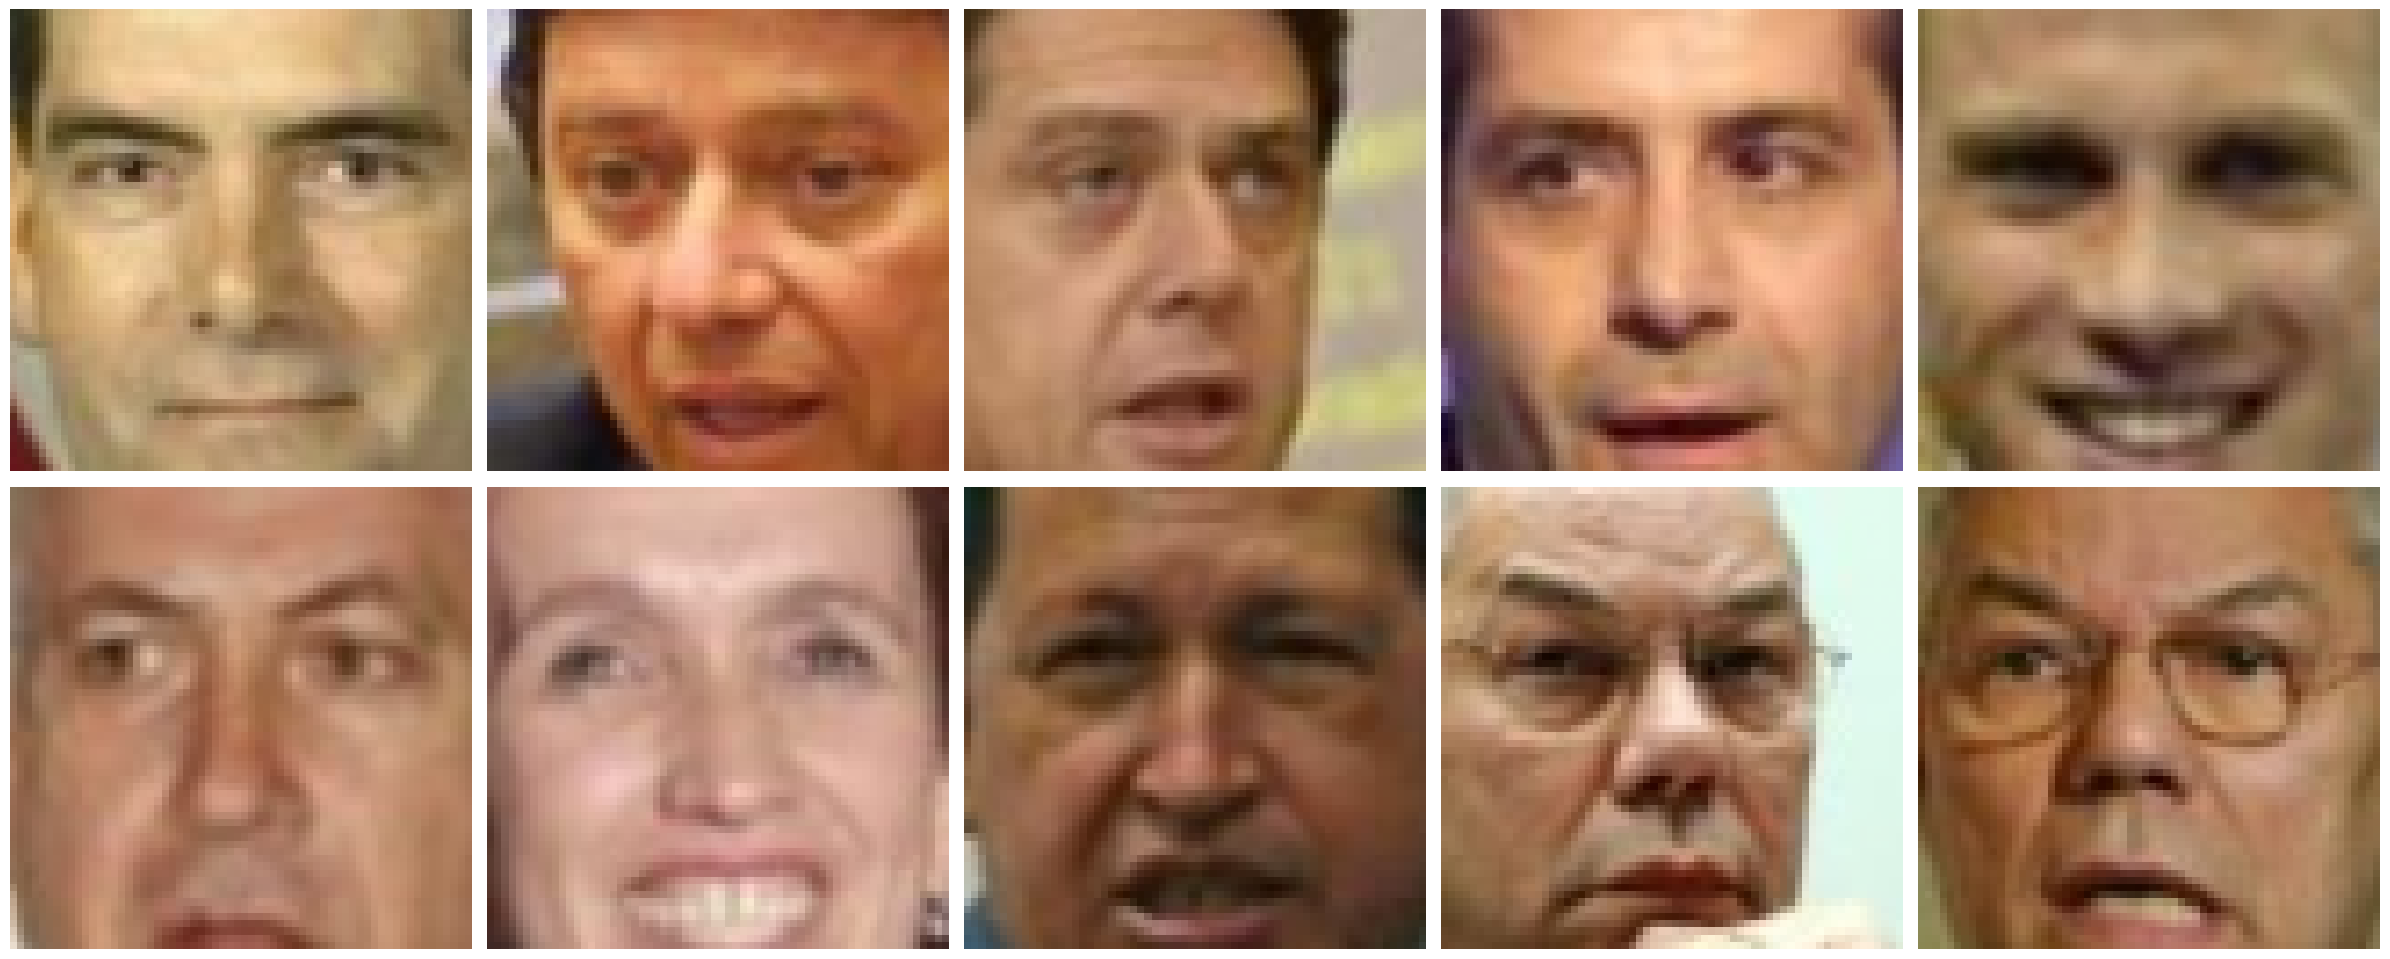

In [11]:
inds = np.random.choice(len(data), 10, replace=False)

plt.subplots(2, 5, figsize=(24, 10))
for i, ind in enumerate(inds):
    plt.subplot(2, 5, i+1)
    plt.imshow(data[ind])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе мы напишем и обучем обычный автоэнкодер.

напомню, что автоэнкодер выглядит вот так:

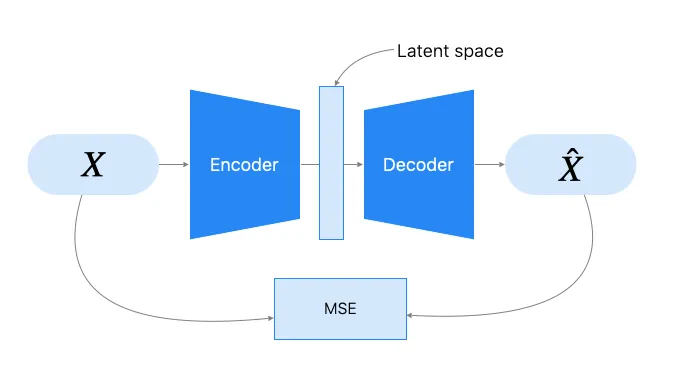

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [12]:
LAYERS = 3
KERNELS = [4, 3, 3]
CHANNELS = [8, 16, 32]
STRIDES = [2, 2, 2]
LATENT_SPACE_DIM=40

In [13]:
class Encoder(nn.Module):
    def __init__(self, latent_space_dim=LATENT_SPACE_DIM, in_channels=3, image_size=(64, 64), use_batchnorm=False, use_dropout=False):
        super().__init__()

        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout

        self.layers = LAYERS
        self.kernels = KERNELS
        self.in_channels = in_channels
        self.channels = CHANNELS
        self.strides = STRIDES

        self.encoder = self._get_encoder()
        self.flatten = nn.Flatten()
        test = self.encoder(torch.randn(size=(1, in_channels, *image_size)))
        self.last_shape = test.shape[1:]
        # print(self.last_shape)
        in_ftr = self.last_shape.numel()
        self.linear = nn.Linear(in_ftr, latent_space_dim)

    def forward(self, x):
        out = self.encoder(x)
        out = self.flatten(out)
        out = self.linear(out)

        return out

    def _get_encoder(self):
        encoder = nn.Sequential()

        for i in range(self.layers):
            encoder.append(
                nn.Conv2d(self.in_channels if i == 0 else self.channels[i-1], self.channels[i],
                          kernel_size=self.kernels[i], stride=self.strides[i])
            )

            if self.use_batchnorm:
                encoder.append(nn.BatchNorm2d(self.channels[i]))

            encoder.append(nn.ReLU())

            if self.use_dropout:
                encoder.append(nn.Dropout(0.3))

        return encoder

In [14]:
class Decoder(nn.Module):
    def __init__(self, in_channels, start_shape, latent_space_dim=LATENT_SPACE_DIM, use_batchnorm=False, use_dropout=False):
        super().__init__()

        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout

        self.layers = LAYERS
        self.kernels = KERNELS[::-1]
        self.in_channels = in_channels
        self.channels = CHANNELS[::-1]
        self.start_shape = start_shape
        self.strides = STRIDES[::-1]

        self.linear = nn.Linear(latent_space_dim, self.start_shape.numel())
        self.decoder = self._get_decoder()

    def forward(self, x):
        out = self.linear(x)
        out = out.reshape(shape=(-1, *self.start_shape))
        out = self.decoder(out)

        return out

    def _get_decoder(self):
        decoder = nn.Sequential()

        for i in range(self.layers):
            decoder.append(
                nn.ConvTranspose2d(self.channels[i], self.in_channels if i == self.layers-1 else self.channels[i+1],
                          kernel_size=self.kernels[i], stride=self.strides[i])
            )

            if self.use_batchnorm and i != self.layers-1:
                decoder.append(nn.BatchNorm2d(self.channels[i]))

            decoder.append(nn.ReLU())

            if self.use_dropout:
                decoder.append(nn.Dropout(0.3))

        return decoder

In [15]:
from copy import deepcopy

class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_space_dim=LATENT_SPACE_DIM, image_size=(64, 64), use_batchnorm=False, use_dropout=False):
        super().__init__()

        self.encoder = Encoder(latent_space_dim=latent_space_dim, in_channels=in_channels, image_size=image_size,
                               use_batchnorm=use_batchnorm, use_dropout=use_dropout)

        self.decoder = Decoder(in_channels, start_shape=self.encoder.last_shape, latent_space_dim=latent_space_dim,
                               use_batchnorm=use_batchnorm, use_dropout=use_dropout)

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)

        return reconstruction, latent_code

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэекодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [16]:
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from IPython.display import clear_output
import torchvision.transforms as T

In [17]:
train_data, val_data = train_test_split(data.astype(np.float32), test_size=0.2, random_state=42)

In [18]:
len(train_data), len(val_data)

(10514, 2629)

In [19]:
trans = T.ToTensor()
train_data = torch.stack([trans(image) for image in train_data])
val_data = torch.stack([trans(image) for image in val_data])

In [20]:
print(type(train_data), type(val_data))
print(train_data.shape, val_data.shape)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([10514, 3, 64, 64]) torch.Size([2629, 3, 64, 64])


In [21]:
batch_size=128
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
                                           shuffle=True, num_workers=2, pin_memory=True)

val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size,
                                         shuffle=True, num_workers=2, pin_memory=True)

In [22]:
def train_epoch(model, train_loader, opt, critetion):
    train_loss = 0
    num_samples = 0

    model.train()
    for x_batch in tqdm(train_loader):
        x_batch = x_batch.to(device)

        out = model(x_batch)
        loss = criterion(out[0], x_batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        num_samples += len(x_batch)

    train_loss /= num_samples
    return train_loss

def val_epoch(model, val_loader, critetion):
    val_loss = 0
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for x_batch in tqdm(val_loader):
            x_batch = x_batch.to(device)

            out = model(x_batch)
            loss = criterion(out[0], x_batch)

            val_loss += loss.item()
            num_samples += len(x_batch)

    val_loss /= num_samples
    return val_loss

In [23]:
def learning_loop(model, train_loader, val_loader, opt, critetion, epochs=10, scheduler=None, history=None, draw_every=1):
    if history is None:
        history = {'train_loss': [], 'val_loss': []}

    plt.subplots(1, 2, figsize=(12, 5))
    plt.grid(visible=True)

    for epoch in range(epochs):
        # clear_output()
        print(f'Epoch {epoch+1}/{epochs}')

        train_loss = train_epoch(model, train_loader, opt, criterion) * 255**2
        val_loss = val_epoch(model, val_loader, criterion) * 255**2
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if scheduler is not None:
            try:
                scheduler.step()
            except:
                scheduler.step(val_loss)

        clear_output()
        print(f'train loss: {train_loss}')
        print(f'val loss: {val_loss}')
        plt.subplot(121)
        plt.plot(history['train_loss'], c='blue', label='Training Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Training Loss')
        plt.ylim(0, 7)

        plt.subplot(122)
        plt.plot(history['val_loss'], c='red', label='Validation Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.ylim(0, 7)

        if (epoch+1) % draw_every == 0:
            with torch.no_grad():
                for x_batch in val_loader:
                    break
            inds = np.random.choice(len(x_batch), 10, replace=False)
            x_batch = x_batch[inds].to(device)
            out = model(x_batch)

            fig, axes = plt.subplots(2, 10, figsize=(15, 5))

            for idx, (image, rec_image) in enumerate(zip(x_batch, out[0])):
                image = image.cpu().detach().numpy().transpose(1, 2, 0)
                rec_image = rec_image.cpu().detach().numpy().transpose(1, 2, 0)

                plt.subplot(2, 10, idx+1)
                plt.imshow(image)
                plt.axis('off')

                plt.subplot(2, 10, idx+11)
                plt.imshow(rec_image)
                plt.axis('off')

        plt.tight_layout()
        plt.show()


    return history

Давайте посмотрим, как наш тренированный автоэекодер кодирует и восстанавливает картинки:

In [24]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [25]:
# autoencoder = Autoencoder().to(device)
autoencoder_upd = Autoencoder().to(device)

criterion = F.mse_loss
opt = optim.Adam(autoencoder_upd.parameters(), lr=3e-3)

In [26]:
for batch in train_loader:
    break
print(batch.dtype)

torch.float32


train loss: 2.278255234776148
val loss: 2.4307006451913424


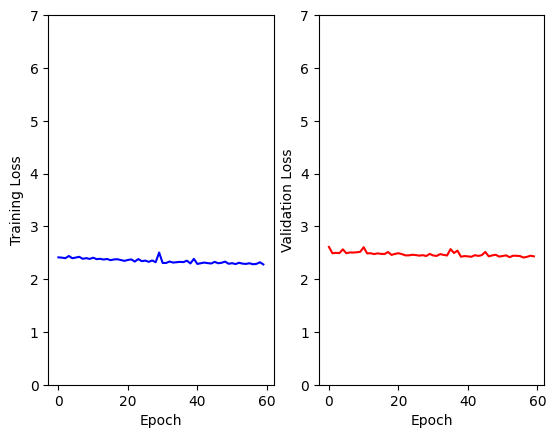

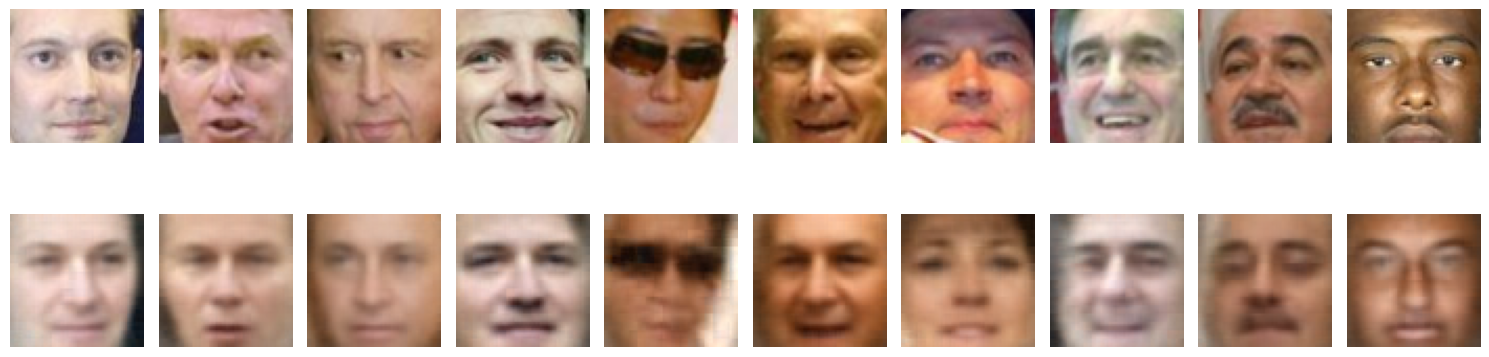

In [49]:
history = learning_loop(autoencoder_upd, train_loader, val_loader, opt, criterion, epochs=60)

In [50]:
autoencoder = autoencoder_upd

In [ ]:
< тут Ваш код: выведите первые Х картинок и их реконструкций из val выборки на экран>

Not bad, right?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэекодер и получать реконструкцию, а попробуем создать что-то НОВОЕ

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__Е сли вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [ ]:
# сгенерируем 25 рандомных векторов размера latent_space
z = np.random.randn(25, LATENT_SPACE_DIM).astype(np.float32)
z = torch.tensor(z)
output = autoencoder.decoder(z)

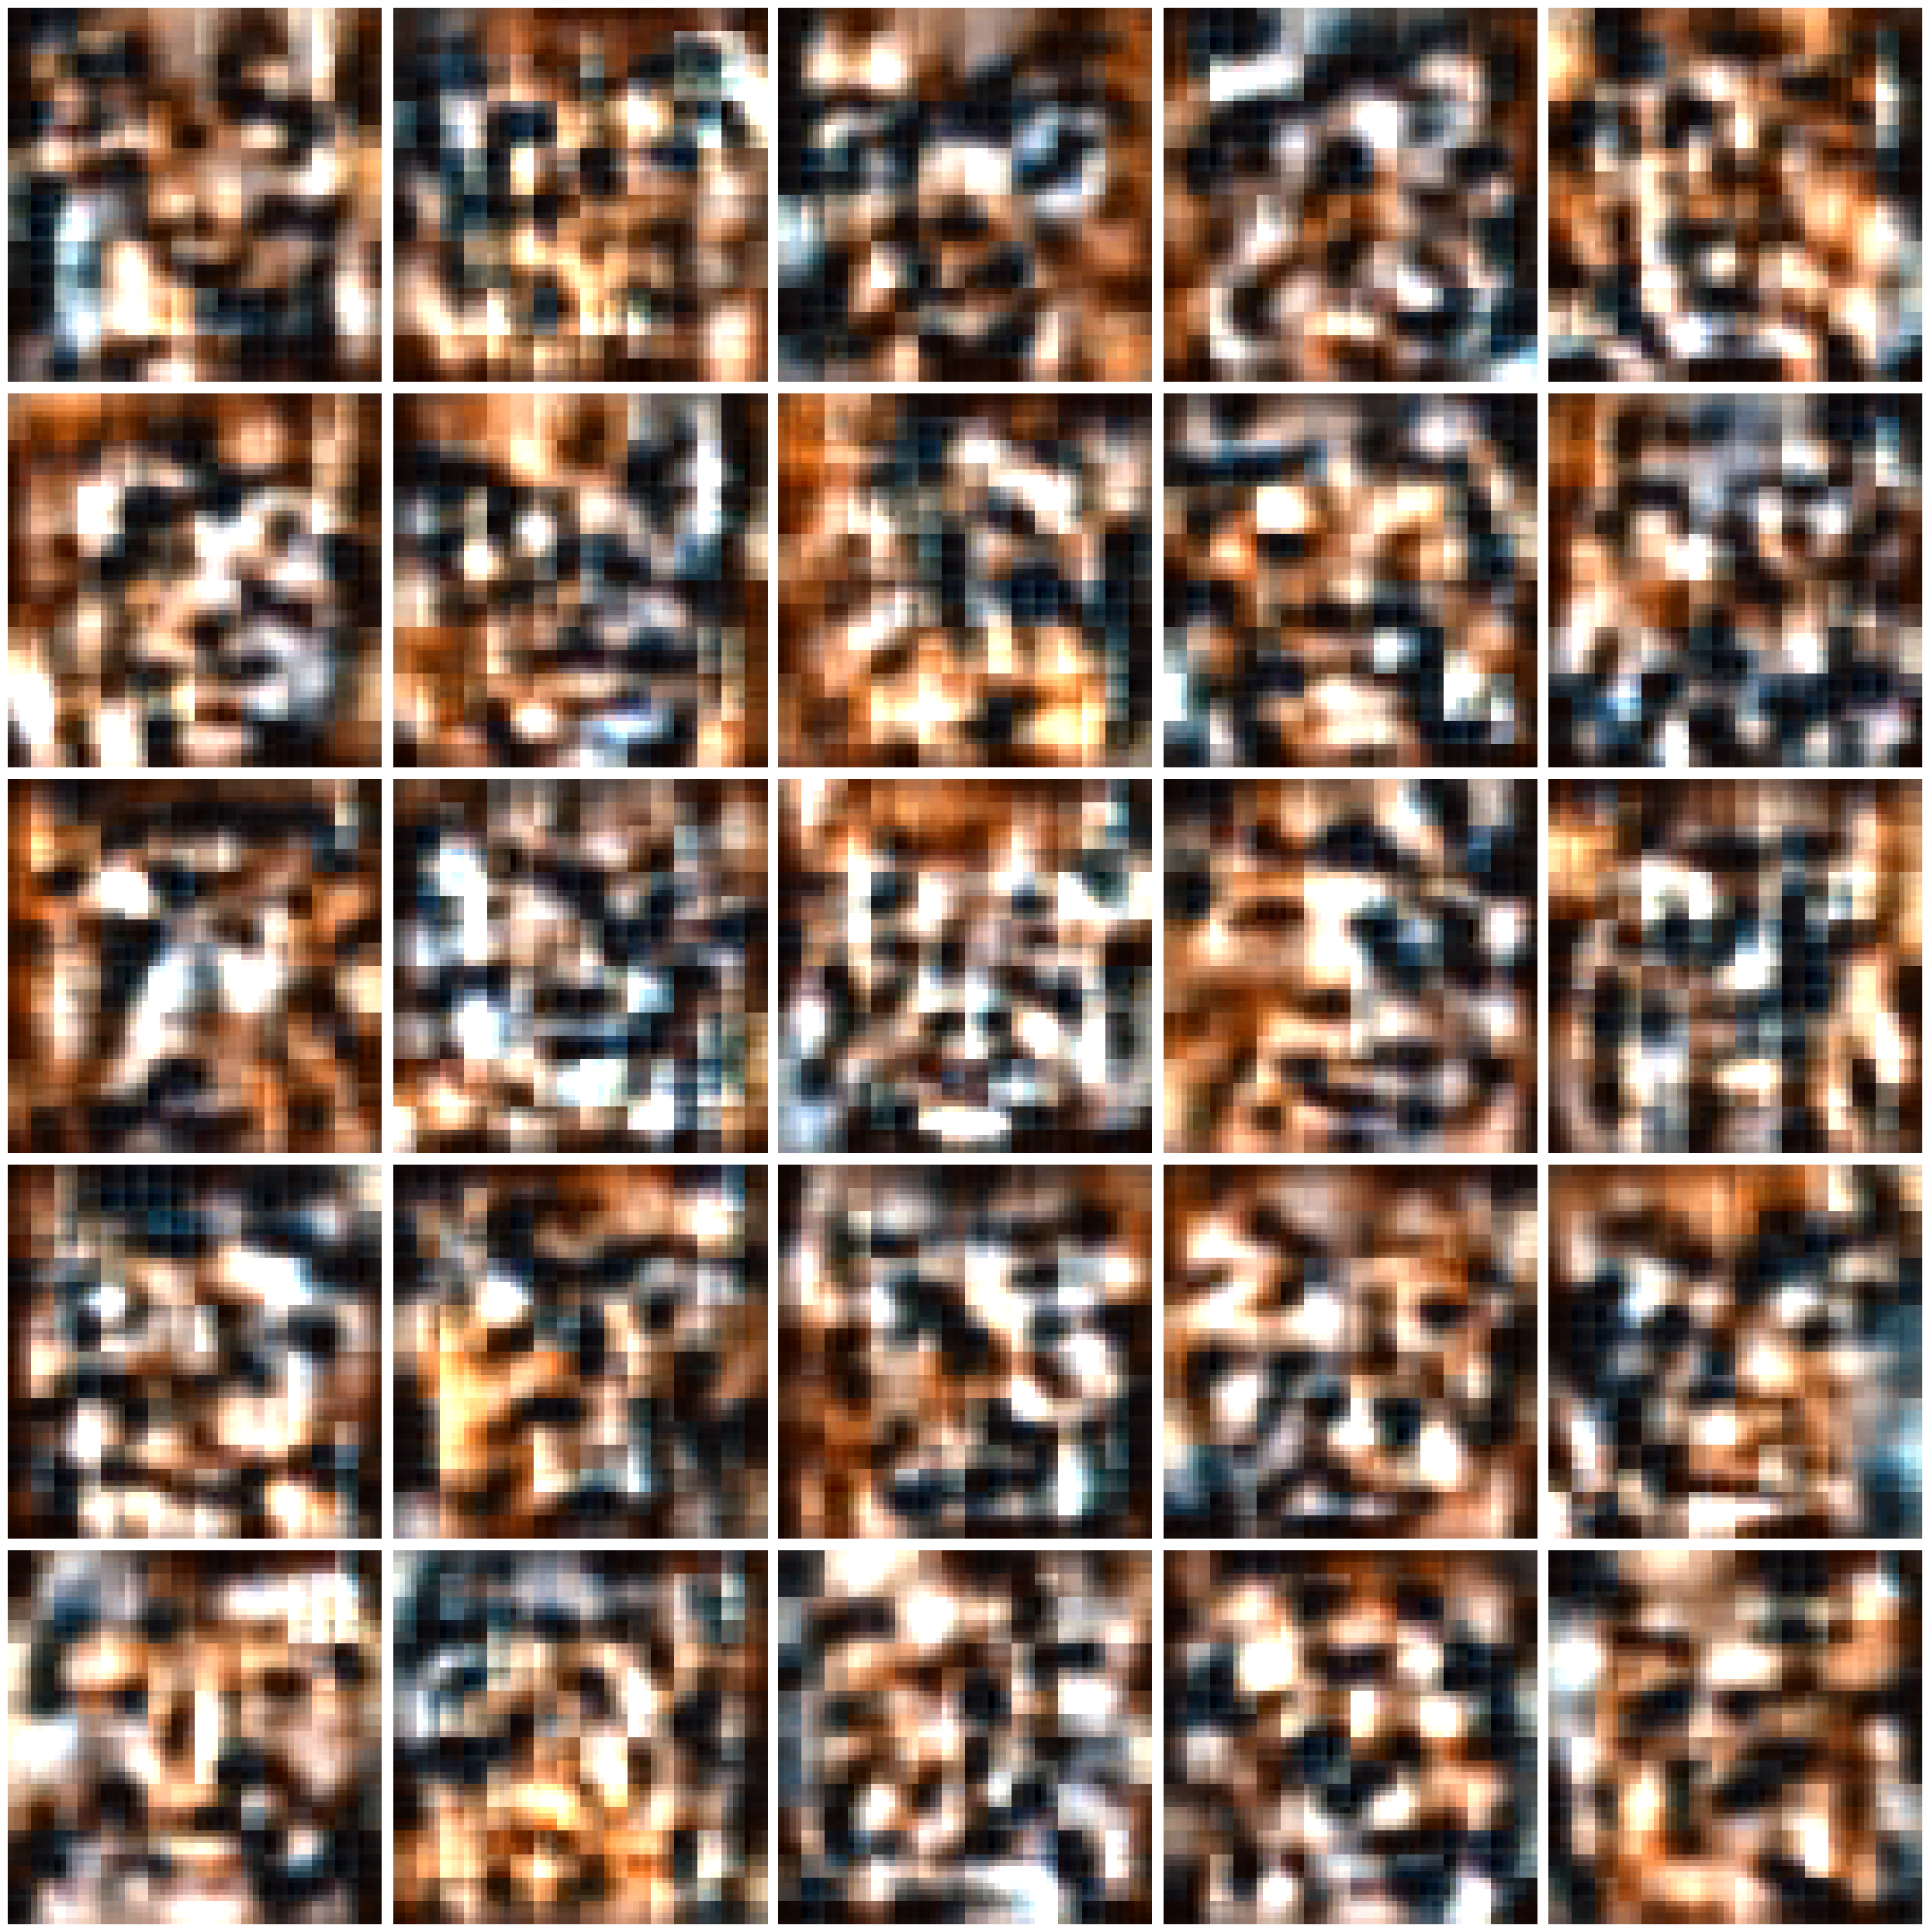

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(25, 25))

for idx, image in enumerate(output):
    image = image.cpu().detach().numpy().transpose(1, 2, 0)

    plt.subplot(5, 5, idx+1)
    plt.imshow(image)
    plt.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
np.linspace(0, 1, 5+1)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

In [ ]:
def emperical_cdf(values):
    values = sorted(values)
    cdf_values = np.linspace(0, 1, len(values)+1)
    return cdf_values[1:], values

In [ ]:
def generate_latent_vectors(size, cdf_values, values):
    res = np.zeros(shape=(size, LATENT_SPACE_DIM))
    for i in range(LATENT_SPACE_DIM):
        u = np.random.uniform(0, 1, size=size)
        res[:, i] = np.interp(u, cdf_values[i], values[i])
    return res


In [ ]:
dataset_latent_vectors = torch.cat([ autoencoder.encoder(batch) for batch in train_loader ], dim=0).cpu().detach().numpy()

In [ ]:
dataset_latent_vectors.shape

(10514, 200)

In [ ]:
emperical_data = [emperical_cdf(dataset_latent_vectors[:, i]) for i in range(LATENT_SPACE_DIM)]

In [ ]:
cdf_values, values = zip(*emperical_data)

In [ ]:
cdf_values, values = np.array(cdf_values), np.array(values)

In [ ]:
cdf_values.shape, values.shape

((200, 10514), (200, 10514))

In [ ]:
test = generate_latent_vectors(25, cdf_values, values)

In [ ]:
output = autoencoder.decoder(torch.tensor(test.astype(np.float32)))

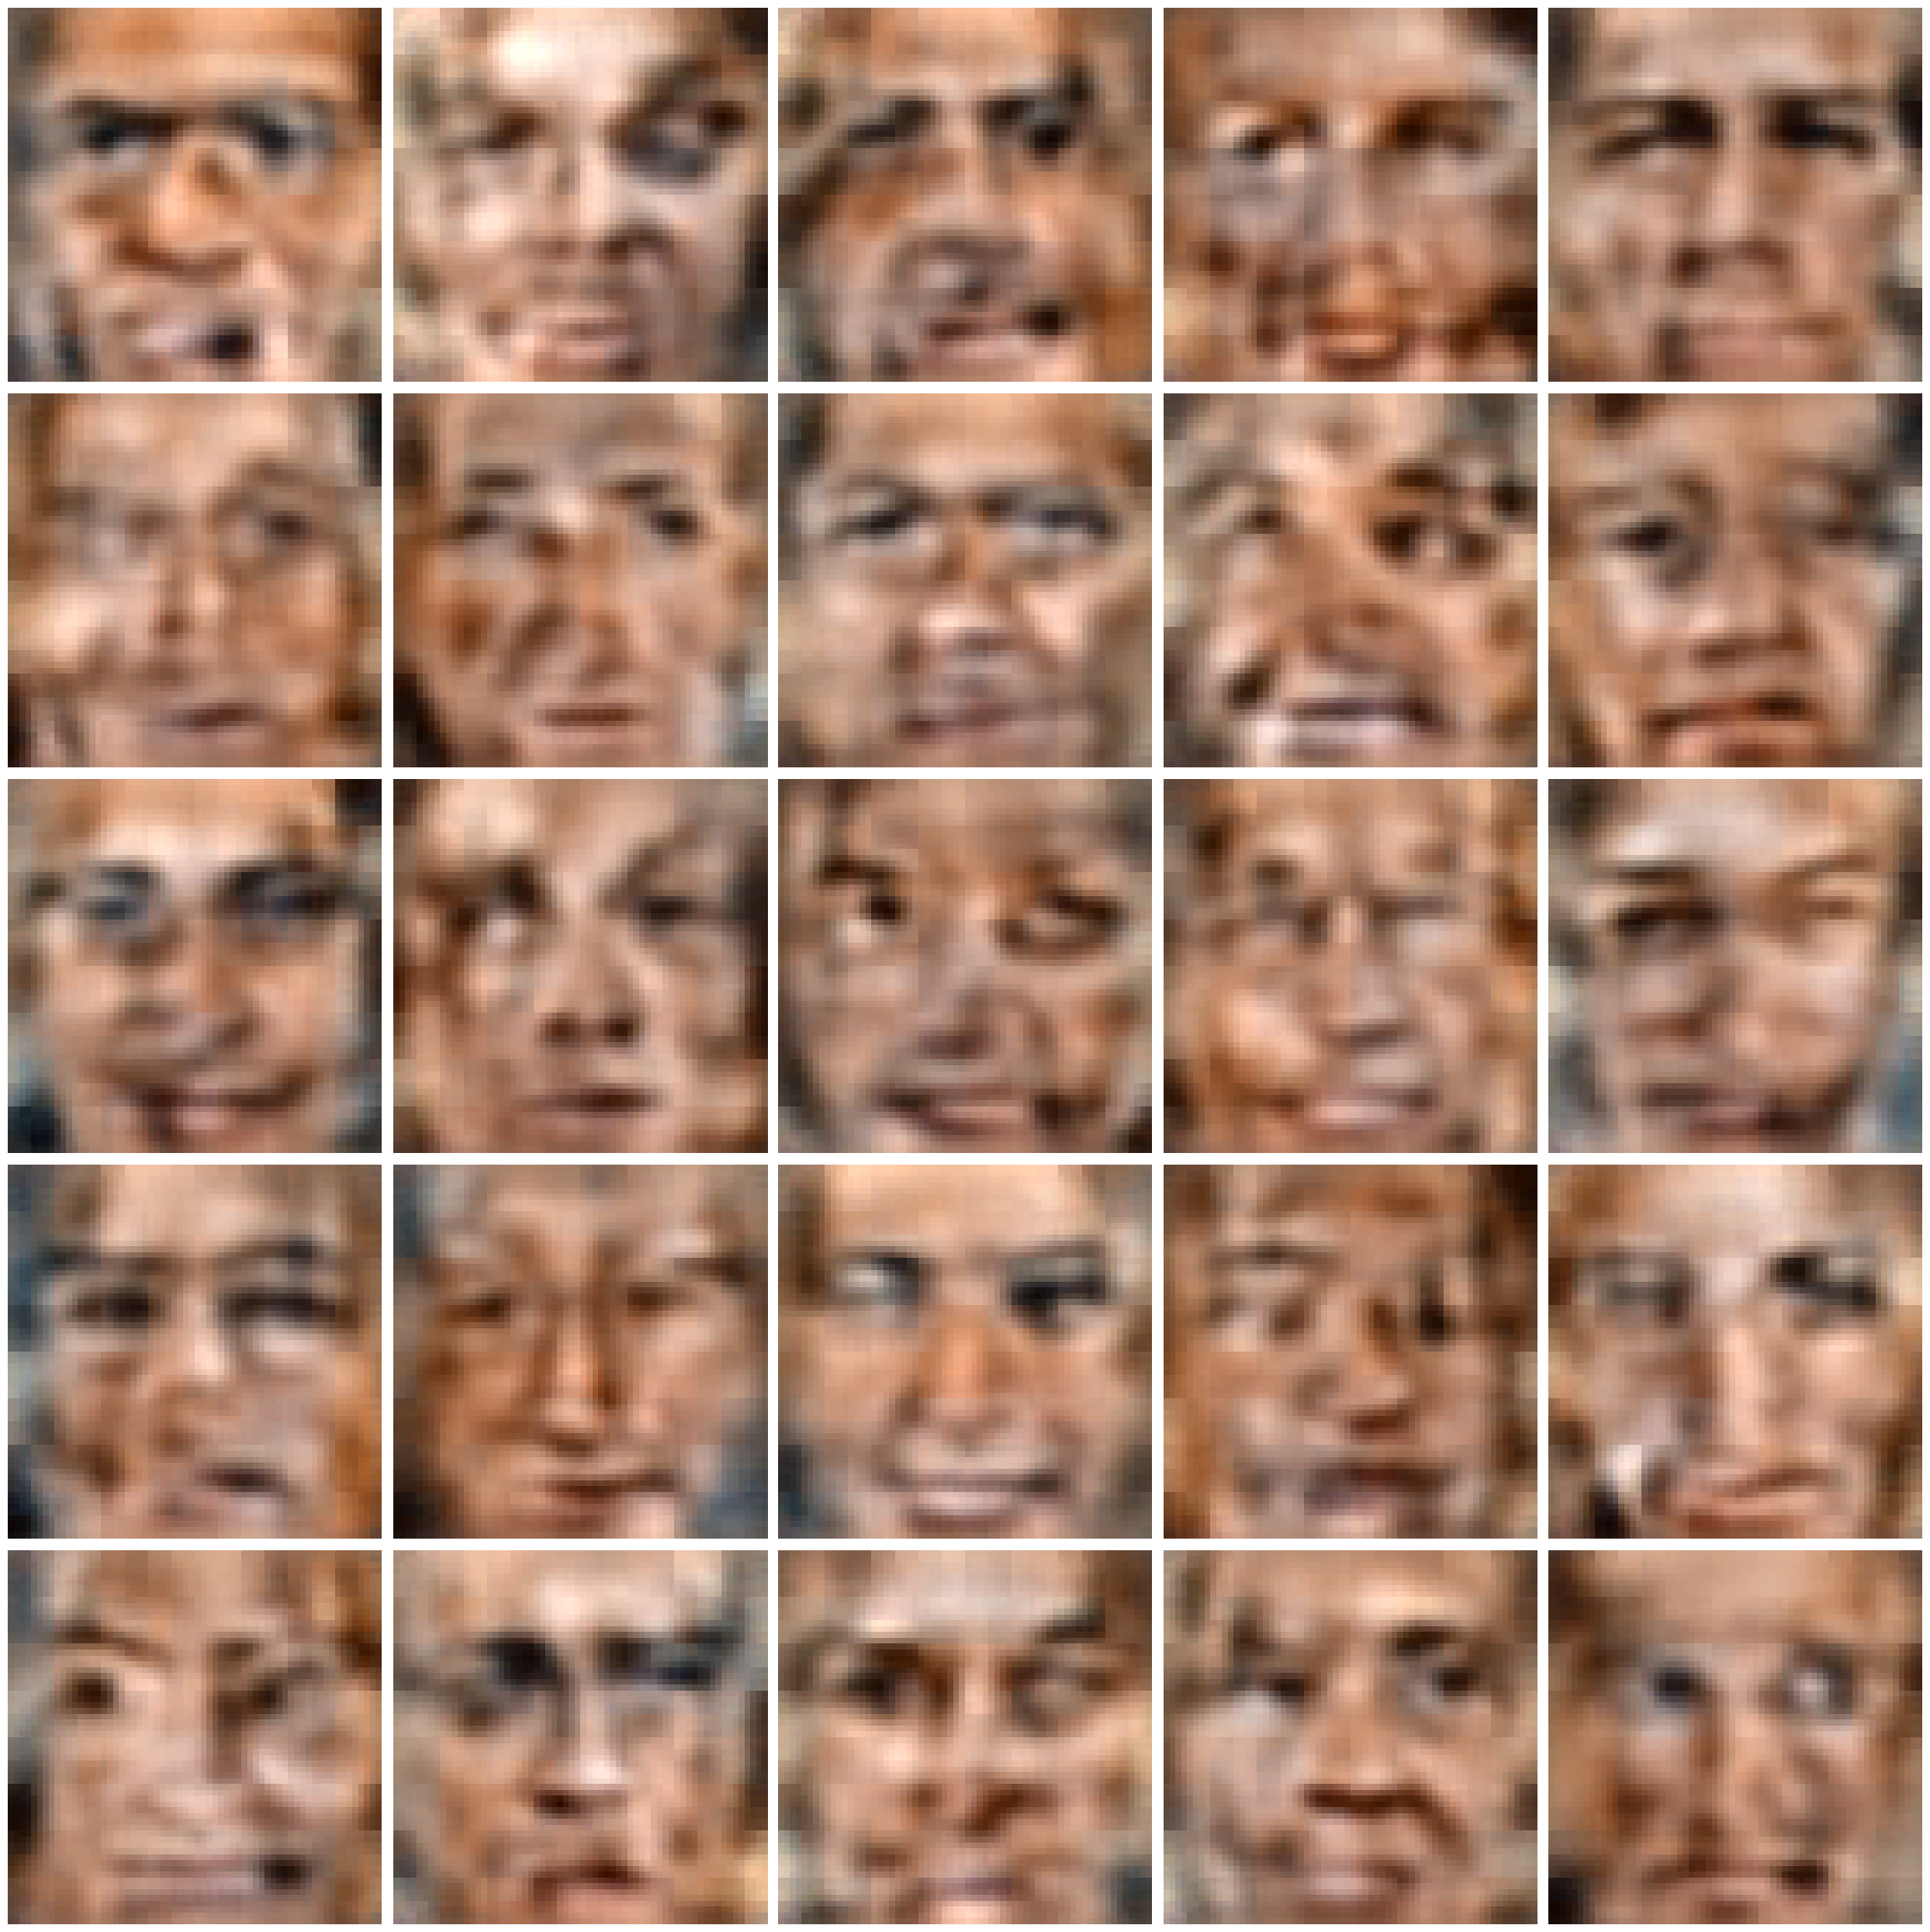

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(25, 25))

for idx, image in enumerate(output):
    image = image.cpu().detach().numpy().transpose(1, 2, 0)

    plt.subplot(5, 5, idx+1)
    plt.imshow(image)
    plt.axis('off')


plt.tight_layout()
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с описанием датасета, скачанный вместе с датасетом. В нем указаны имена картинок и присутствубщие атрибуты (улыбки, очки...)

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [ ]:
attrs['Smiling']

,Smiling
0,-0.86499
1,0.798544
2,0.172817
3,0.563327
4,0.507786
...,...
13138,-1.001434
13139,-0.64957
13140,0.475018
13141,0.741653


<Axes: ylabel='Density'>

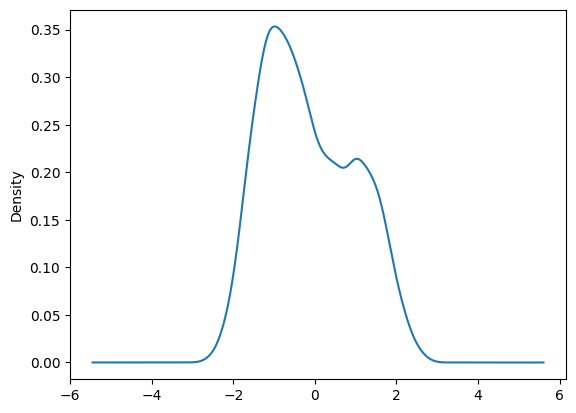

In [ ]:
attrs['Smiling'].plot.kde()

In [ ]:
attrs[attrs['Smiling'] > 0]['Smiling']

,Smiling
1,0.798544
2,0.172817
3,0.563327
4,0.507786
5,1.32771
...,...
13132,0.089951
13133,0.097648
13137,0.985911
13140,0.475018


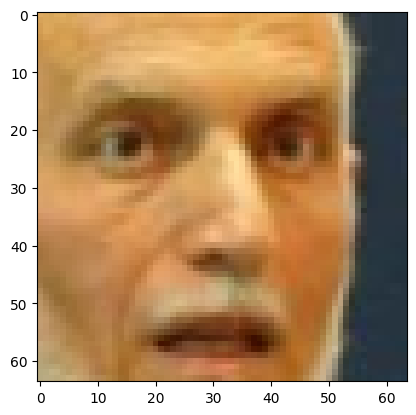

In [ ]:
plt.imshow(data[48])

In [ ]:
attrs[attrs['Smiling'] < -0.5]['Smiling']

,Smiling
0,-0.86499
6,-1.251005
7,-0.939041
10,-1.223304
13,-0.54646
...,...
13135,-0.68763
13136,-1.121944
13138,-1.001434
13139,-0.64957


In [ ]:
smiling_inds = attrs[attrs['Smiling'] > 0.5][:25].index
not_smiling_inds = attrs[attrs['Smiling'] < -0.5][:25].index
print(smiling_inds)
print(not_smiling_inds)

Index([  1,   3,   4,   5,   8,   9,  11,  18,  26,  33,  34,  52,  60,  83,
        84,  88,  96,  98, 101, 102, 106, 108, 130, 132, 135],
      dtype='int64')
Index([ 0,  6,  7, 10, 13, 14, 15, 16, 17, 22, 24, 25, 29, 40, 48, 49, 50, 53,
       55, 56, 59, 61, 62, 63, 65],
      dtype='int64')


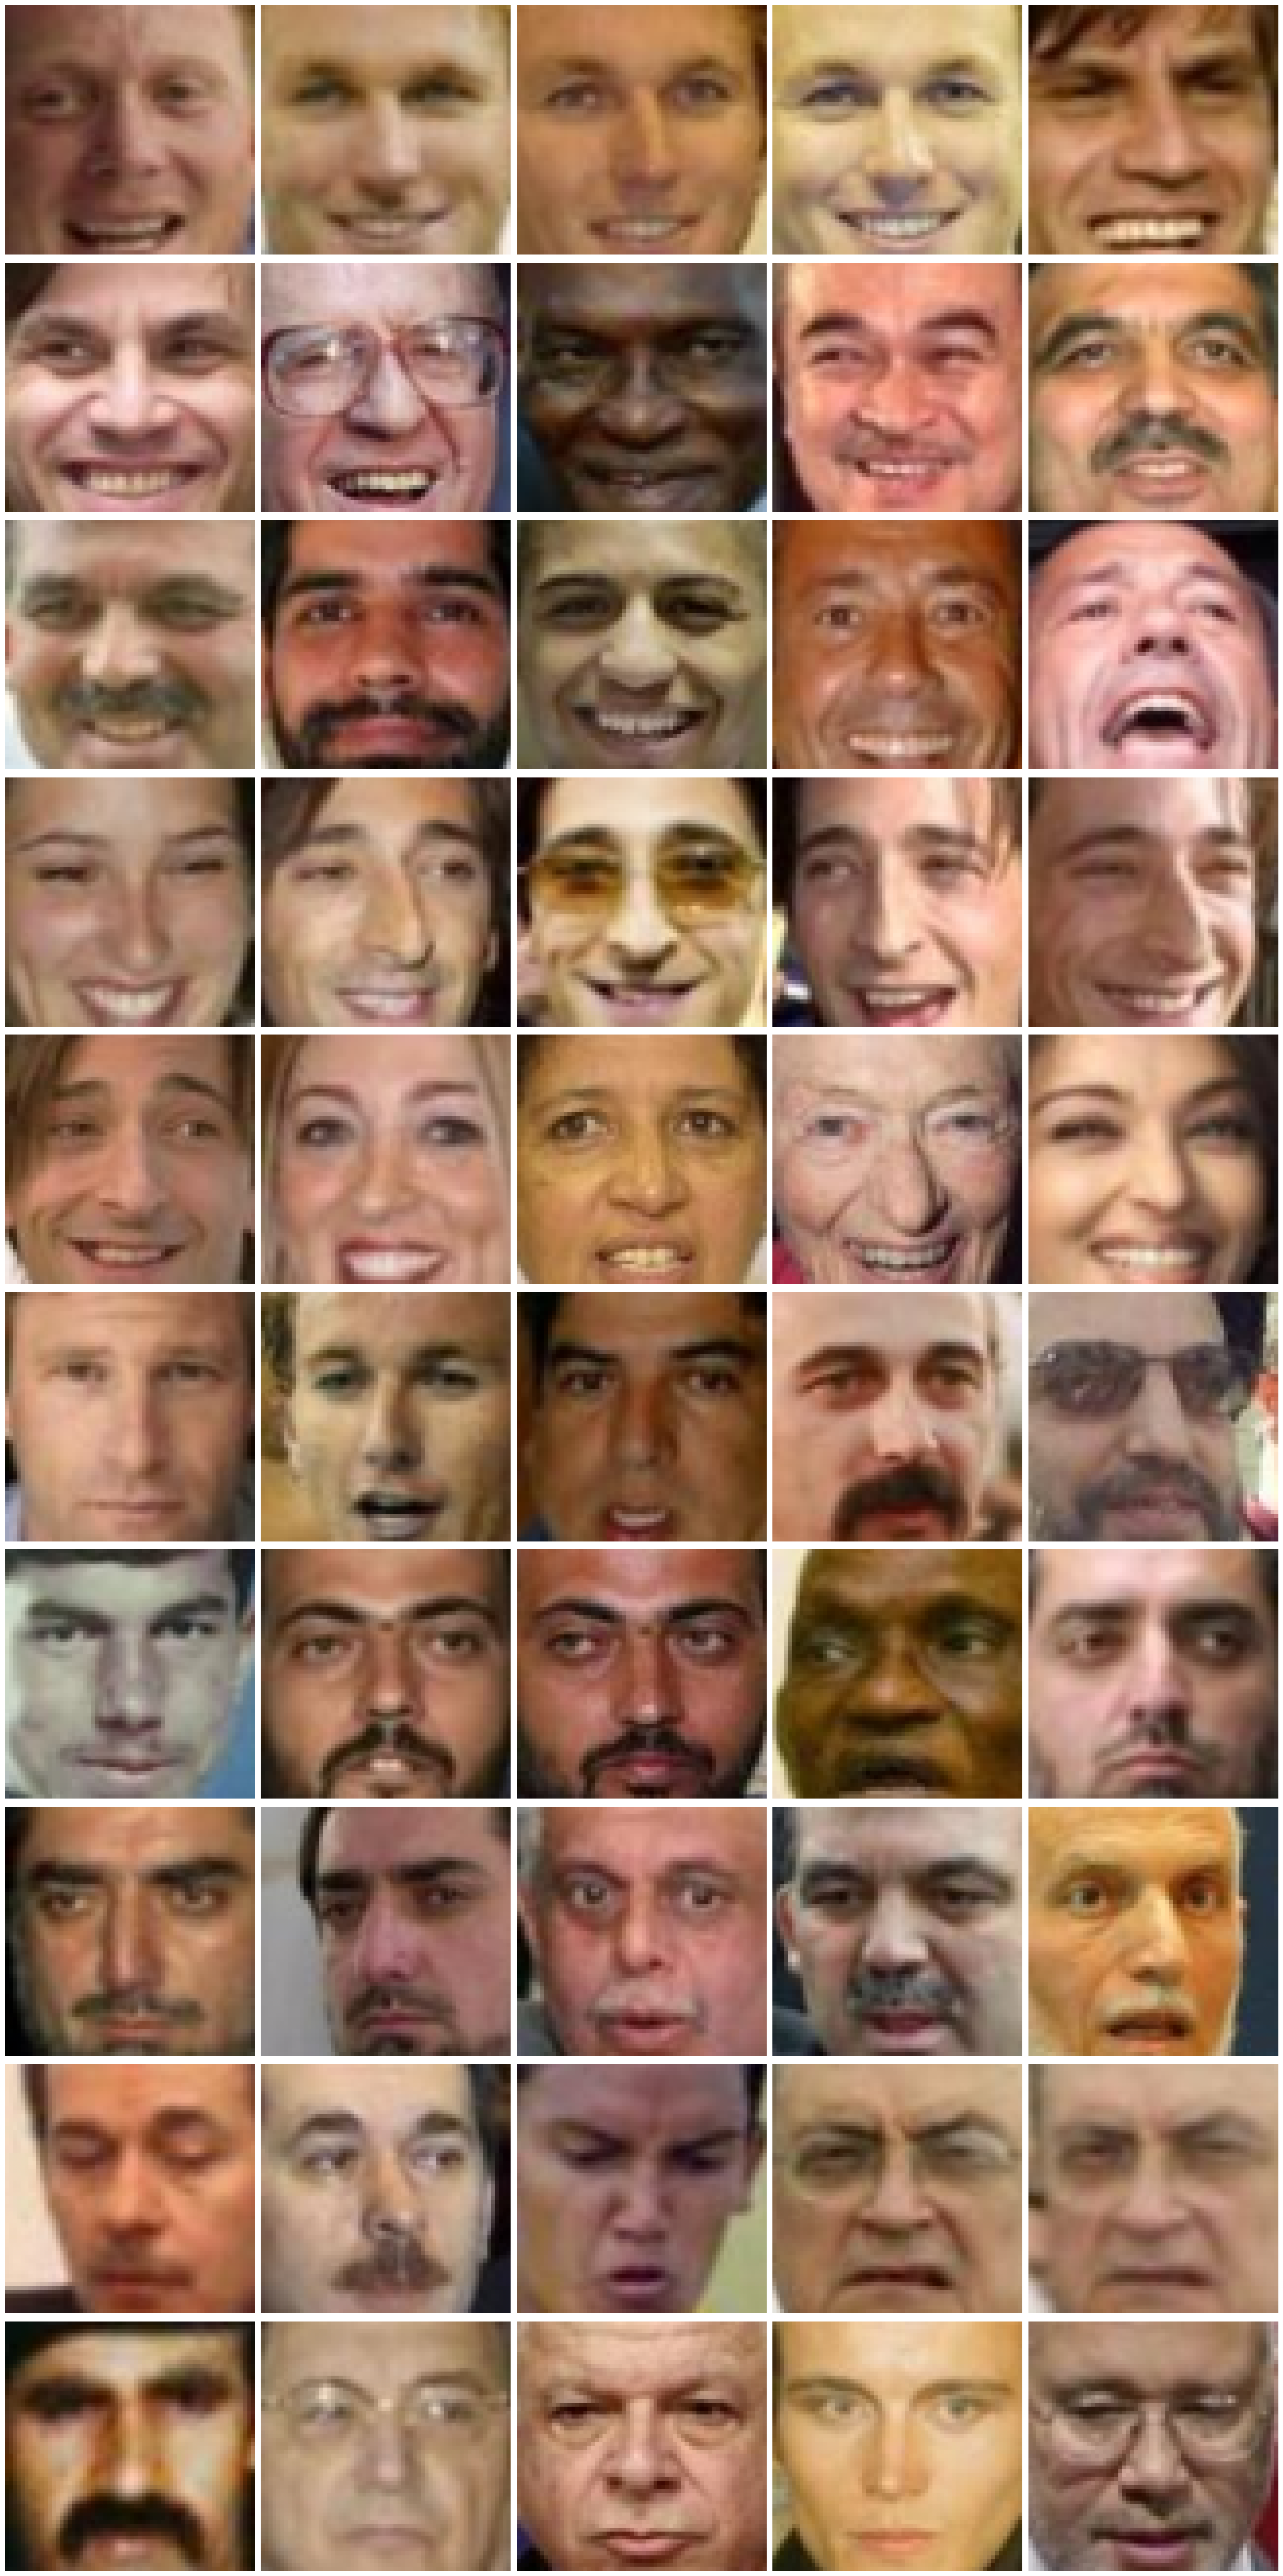

In [ ]:
fig, axes = plt.subplots(10, 5, figsize=(25, 50))

for idx, (ind1, ind2) in enumerate(zip(smiling_inds, not_smiling_inds)):
    plt.subplot(10, 5, idx+1)
    plt.imshow(data[ind1])
    plt.axis('off')

    plt.subplot(10, 5, idx+26)
    plt.imshow(data[ind2])
    plt.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
smiling_images = train_data[smiling_inds]
not_smiling_images = train_data[not_smiling_inds]

In [ ]:
smile_latent_vector = autoencoder(smiling_images)[1].mean(dim=0)
not_smile_latent_vector = autoencoder(not_smiling_images)[1].mean(dim=0)
print(smile_latent_vector.shape)

torch.Size([200])


In [ ]:
new_not_smiling_images = not_smiling_images
new_not_smiling_latent_vectors = autoencoder.encoder(new_not_smiling_images)
new_smiling_images = autoencoder.decoder(new_not_smiling_latent_vectors + smile_latent_vector - not_smile_latent_vector)

In [ ]:
fig, axes = plt.subplots(25, 2, figsize=(4,  50))

for idx, (image1, image2) in enumerate(zip(not_smiling_images, new_smiling_images)):
    image1 = image1.cpu().detach().numpy().transpose(1, 2, 0)
    image2 = image2.cpu().detach().numpy().transpose(1, 2, 0)

    plt.subplot(25, 2, idx * 2 + 1)
    plt.imshow(image1)
    plt.axis('off')

    plt.subplot(25, 2, idx * 2 + 2)
    plt.imshow(image2)
    plt.axis('off')


plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... в общем, все, на что хватит фантазии и на что есть атрибуты в `all_attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [27]:
from torchvision import transforms

In [28]:
batch_size = 128
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.27MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [29]:
type(train_dataset), len(train_dataset)

(torchvision.datasets.mnist.MNIST, 60000)

In [30]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [31]:
np.unique(train_dataset[0][0].numpy().transpose(1, 2, 0))

array([0.        , 0.00392157, 0.00784314, 0.01176471, 0.03529412,
       0.04313726, 0.05490196, 0.0627451 , 0.07058824, 0.09019608,
       0.09411765, 0.09803922, 0.10196079, 0.10588235, 0.11764706,
       0.13725491, 0.14117648, 0.15294118, 0.16862746, 0.1764706 ,
       0.18039216, 0.19215687, 0.21568628, 0.21960784, 0.2509804 ,
       0.25882354, 0.27450982, 0.30588236, 0.3137255 , 0.31764707,
       0.32156864, 0.3529412 , 0.3647059 , 0.36862746, 0.41960785,
       0.42352942, 0.44705883, 0.46666667, 0.49411765, 0.49803922,
       0.50980395, 0.5176471 , 0.52156866, 0.5294118 , 0.53333336,
       0.54509807, 0.5803922 , 0.5882353 , 0.6039216 , 0.6117647 ,
       0.627451  , 0.6509804 , 0.6666667 , 0.67058825, 0.6745098 ,
       0.6862745 , 0.7137255 , 0.7176471 , 0.7294118 , 0.73333335,
       0.74509805, 0.7647059 , 0.7764706 , 0.7882353 , 0.8039216 ,
       0.8117647 , 0.83137256, 0.8352941 , 0.85882354, 0.8666667 ,
       0.88235295, 0.8862745 , 0.8980392 , 0.93333334, 0.94117

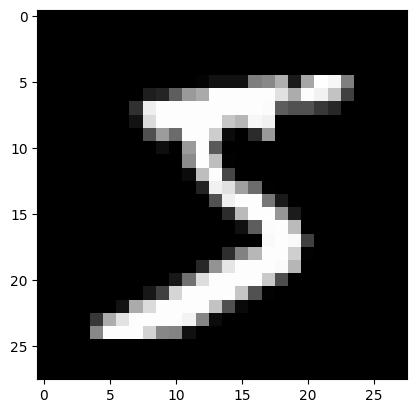

In [32]:
plt.imshow(train_dataset[0][0].numpy().transpose(1, 2, 0), cmap='gray')

In [33]:
autoencoder = Autoencoder()

In [34]:
autoencoder.eval()
autoencoder.training

False

In [35]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.l1 = nn.Linear(784, 200)
        self.l21 = nn.Linear(200, 20)
        self.l22 = nn.Linear(200, 20)
        self.l3 = nn.Linear(20, 200)
        self.l4 = nn.Linear(200, 784)

    def encode(self, x):
        enc = F.relu(self.l1(x))
        mu, logsigma = self.l21(enc), self.l22(enc)

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std=torch.exp(logsigma)
            eps=torch.randn_like(std)
            return mu + eps * std

        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z):
        dec = F.relu(self.l3(z))
        reconstruction = F.sigmoid(self.l4(dec))

        return reconstruction

    def forward(self, x):
        # print(x.shape)
        # x = x.view(-1, 784)
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [36]:
torch.tensor([1,2 ]).pow(2) + torch.tensor([1])

tensor([2, 5])

In [304]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * (1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma)).sum()
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy
    return loss(reconstruction, x, reduction='sum')

def wrapper(beta=1):
    def loss_vae(x, mu, logsigma, reconstruction, beta=beta):
        a, b = log_likelihood(x, reconstruction), KL_divergence(mu, logsigma)
        print(f"Reconstruction loss: {a}")
        print(f"{beta} * KL Divergence: {beta * b}")
        return log_likelihood(x, reconstruction) + beta * KL_divergence(mu, logsigma)
    return loss_vae

И обучим модель:

In [305]:
def train_epoch(model, train_loader, opt, critetion):
    train_loss = 0
    num_samples = 0

    model.train()
    for x_batch, y_batch in tqdm(train_loader):
        x_batch = x_batch.view(-1, 784).to(device)

        mu, logsigma, reconstruction = model(x_batch)
        loss = criterion(x_batch, mu, logsigma, reconstruction)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        num_samples += len(x_batch)

    train_loss /= num_samples
    return train_loss

def val_epoch(model, val_loader, critetion):
    val_loss = 0
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in tqdm(val_loader):
            x_batch = x_batch.view(-1, 784).to(device)

            mu, logsigma, reconstruction = model(x_batch)
            loss = criterion(x_batch, mu, logsigma, reconstruction)

            val_loss += loss.item()
            num_samples += len(x_batch)

    val_loss /= num_samples
    return val_loss

In [306]:
def learning_loop(model, train_loader, val_loader, opt, critetion, epochs=10, scheduler=None, history=None, draw_every=1):
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'lr': []}

    plt.subplots(1, 3)
    plt.grid(visible=True)

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')

        train_loss = train_epoch(model, train_loader, opt, criterion)
        val_loss = val_epoch(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(opt.param_groups[0]['lr'])

        if scheduler is not None:
            try:
                scheduler.step()
            except:
                scheduler.step(val_loss)

        clear_output()
        print(f'train loss: {train_loss}')
        print(f'val loss: {val_loss}')
        plt.figure(figsize=(24, 6))
        plt.subplot(131)
        plt.plot(history['train_loss'], c='blue', label='Training Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Training Loss')
        plt.ylim(95, 117)

        plt.subplot(132)
        plt.plot(history['val_loss'], c='red', label='Validation Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.ylim(95, 117)

        plt.subplot(133)
        plt.plot(history['lr'], c='green', label='Learning Rate curve')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        # plt.ylim(95, 117)

        if (epoch+1) % draw_every == 0:
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    break
            inds = np.random.choice(len(x_batch), 10, replace=False)
            x_batch = x_batch[inds].view(-1, 784).to(device)
            _, _, reconstruction = model(x_batch)

            fig, axes = plt.subplots(2, 10, figsize=(15, 5))

            for idx, (image, rec_image) in enumerate(zip(x_batch, reconstruction)):
                image = image.cpu().detach().numpy().reshape(28, 28, 1)
                rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

                plt.subplot(2, 10, idx+1)
                plt.imshow(image, cmap='gray')
                plt.axis('off')

                plt.subplot(2, 10, idx+11)
                plt.imshow(rec_image, cmap='gray')
                plt.axis('off')

        # plt.tight_layout()
        plt.show()



    return history

In [312]:
criterion = wrapper(beta=3)

autoencoder = VAE().to(device)

opt = torch.optim.AdamW(autoencoder.parameters(), weight_decay=1e-2, lr=3e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=4)

In [313]:
for x_batch in test_loader:
    break

In [314]:
type(x_batch), x_batch[0].shape, x_batch[1].shape

(list, torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [315]:
len(test_loader)

79

train loss: 137.76814755859374
val loss: 123.67548273925782


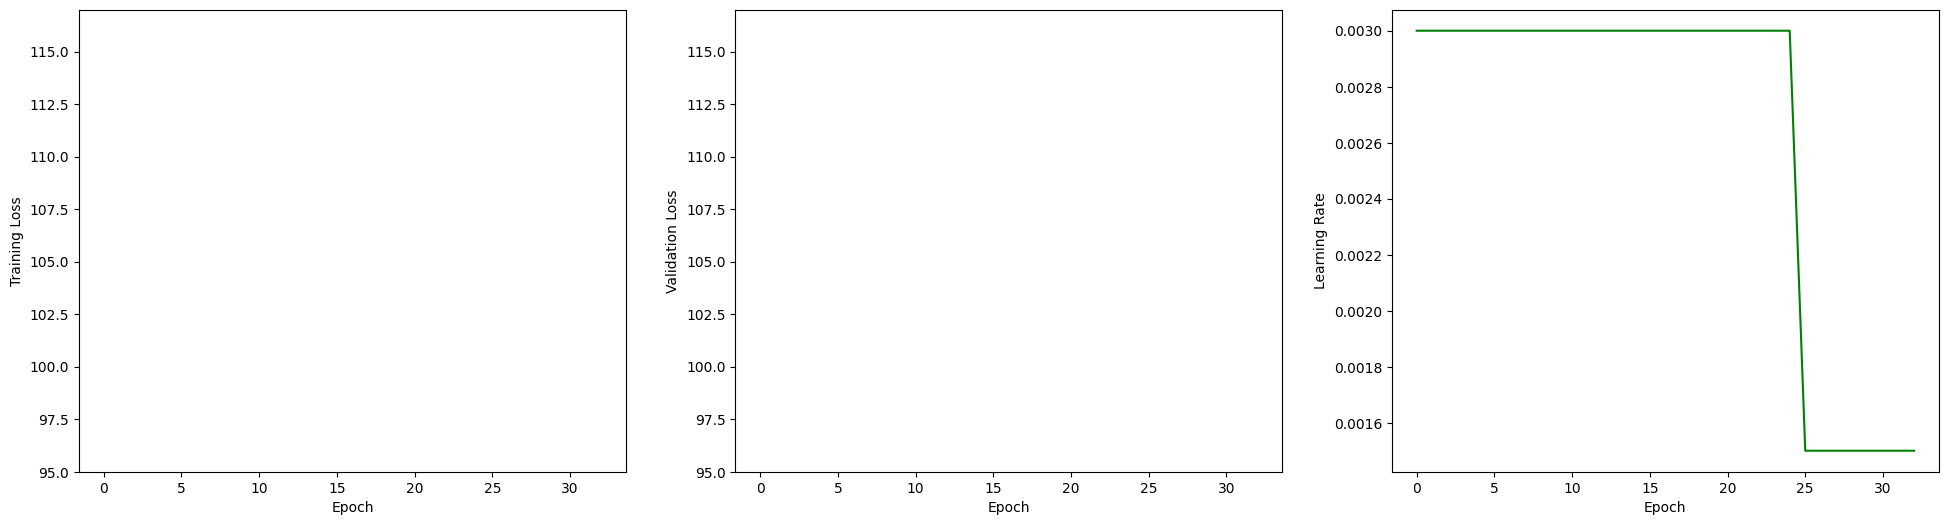

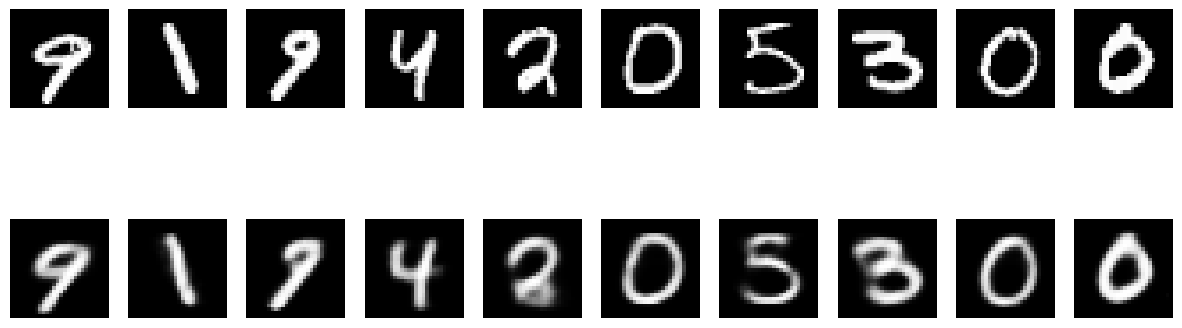

Epoch 34/50


  0%|          | 0/469 [00:00<?, ?it/s]

Reconstruction loss: 13409.66796875
3 * KL Divergence: 4465.00390625
Reconstruction loss: 12602.9326171875
3 * KL Divergence: 4435.974609375
Reconstruction loss: 13461.5625
3 * KL Divergence: 4518.9794921875
Reconstruction loss: 13254.08203125
3 * KL Divergence: 4415.369140625
Reconstruction loss: 13775.673828125
3 * KL Divergence: 4286.669921875
Reconstruction loss: 13060.88671875
3 * KL Divergence: 4229.65234375
Reconstruction loss: 13753.58984375
3 * KL Divergence: 4510.71484375
Reconstruction loss: 12630.681640625
3 * KL Divergence: 4266.5087890625
Reconstruction loss: 13784.5869140625
3 * KL Divergence: 4587.57421875
Reconstruction loss: 13038.50390625
3 * KL Divergence: 4453.69775390625
Reconstruction loss: 13114.6171875
3 * KL Divergence: 4411.783203125
Reconstruction loss: 13417.458984375
3 * KL Divergence: 4464.787109375
Reconstruction loss: 13556.51171875
3 * KL Divergence: 4367.0419921875
Reconstruction loss: 13454.9658203125
3 * KL Divergence: 4421.62109375
Reconstruction l

KeyboardInterrupt: 

In [316]:
history=learning_loop(autoencoder, train_loader, test_loader, opt, criterion, epochs=50, scheduler=scheduler)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

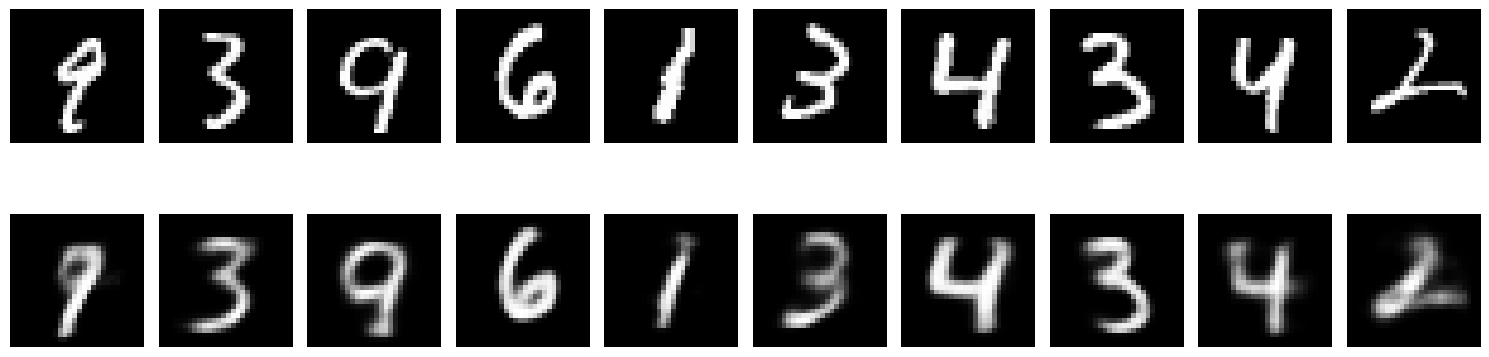

In [320]:
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        break
inds = np.random.choice(len(x_batch), 10, replace=False)
x_batch = x_batch[inds].view(-1, 784).to(device)
_, _, reconstruction = autoencoder(x_batch)

fig, axes = plt.subplots(2, 10, figsize=(15, 5))

for idx, (image, rec_image) in enumerate(zip(x_batch, reconstruction)):
    image = image.cpu().detach().numpy().reshape(28, 28, 1)
    rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

    plt.subplot(2, 10, idx+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 10, idx+11)
    plt.imshow(rec_image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [321]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = np.array([np.random.normal(0, 1, 20) for i in range(30)]).astype(np.float32)
output = autoencoder.decode(torch.tensor(z).to(device))

In [322]:
output.shape

torch.Size([30, 784])

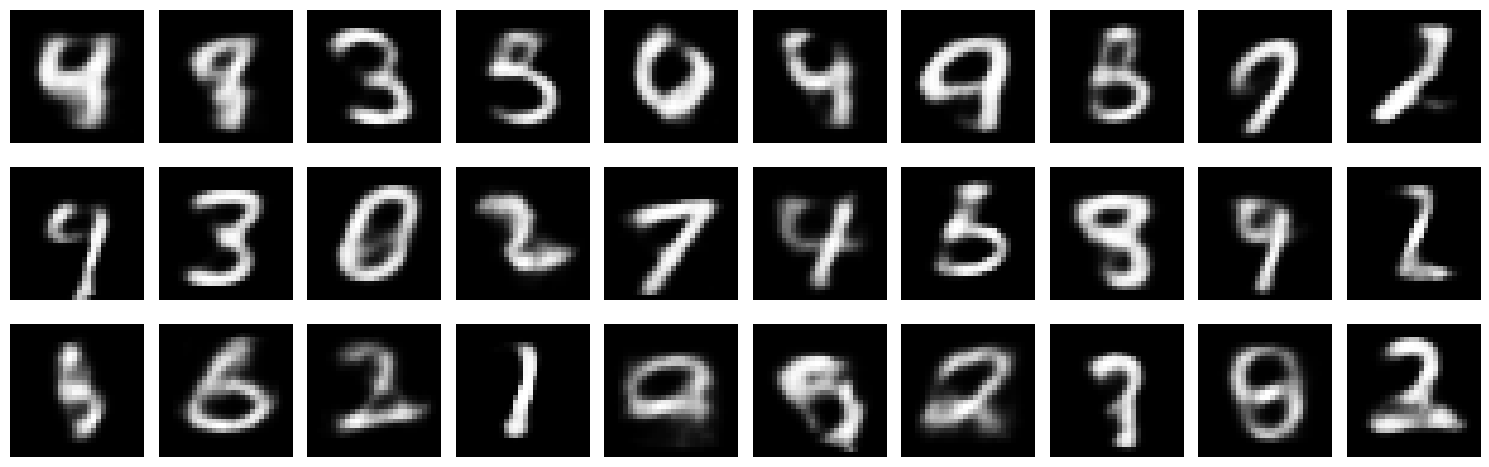

In [326]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for idx, rec_image in enumerate(output):
    rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

    plt.subplot(3, 10, idx+1)
    plt.imshow(rec_image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [327]:
dataset_latent_vectors, dataset_labels = zip(*[ (autoencoder.encode(x_batch.view(-1, 784).to(device))[0], y_batch) for x_batch, y_batch in train_loader])

In [328]:
dataset_labels = torch.cat(dataset_labels)
dataset_latent_vectors = torch.cat(dataset_latent_vectors, axis=0)

In [329]:
dataset_latent_vectors.shape

torch.Size([60000, 20])

In [330]:
import sklearn

In [331]:
compressed_vectors, compressed_labels = dataset_latent_vectors[:5000], dataset_labels[:5000]
compressed_vectors.shape

torch.Size([5000, 20])

In [332]:
tsne_vectors = sklearn.manifold.TSNE(n_components=2, perplexity=10, verbose=1).fit_transform(compressed_vectors.cpu().detach().numpy())

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.270s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.650731
[t-SNE] KL divergence after 250 iterations with early exaggeration: 87.634666
[t-SNE] KL divergence after 1000 iterations: 1.680395


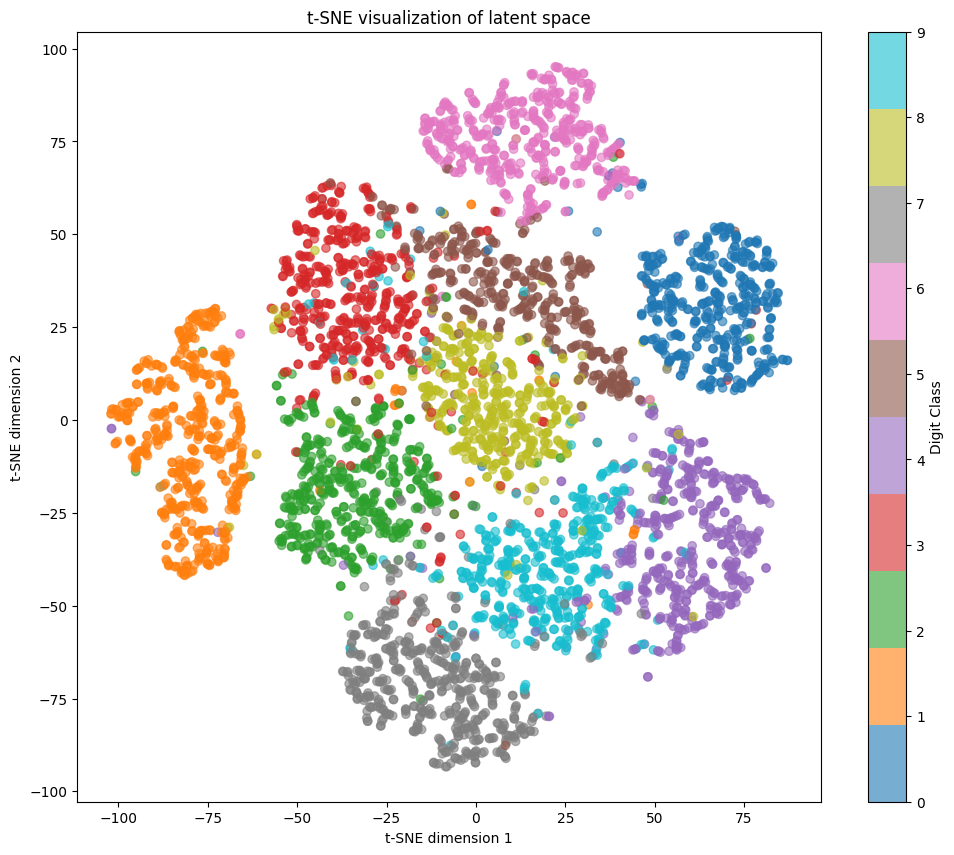

In [333]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_vectors[:, 0], tsne_vectors[:, 1], c=compressed_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Class')
plt.title('t-SNE visualization of latent space')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

Что вы думаете о виде латентного представления?

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



## 2.1 Архитектура модели и обучение (2 балла)

Реализуем СVAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [334]:
type(train_dataset), len(train_dataset)

(torchvision.datasets.mnist.MNIST, 60000)

In [335]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [336]:
np.unique(train_dataset[0][0].numpy().transpose(1, 2, 0))

array([0.        , 0.00392157, 0.00784314, 0.01176471, 0.03529412,
       0.04313726, 0.05490196, 0.0627451 , 0.07058824, 0.09019608,
       0.09411765, 0.09803922, 0.10196079, 0.10588235, 0.11764706,
       0.13725491, 0.14117648, 0.15294118, 0.16862746, 0.1764706 ,
       0.18039216, 0.19215687, 0.21568628, 0.21960784, 0.2509804 ,
       0.25882354, 0.27450982, 0.30588236, 0.3137255 , 0.31764707,
       0.32156864, 0.3529412 , 0.3647059 , 0.36862746, 0.41960785,
       0.42352942, 0.44705883, 0.46666667, 0.49411765, 0.49803922,
       0.50980395, 0.5176471 , 0.52156866, 0.5294118 , 0.53333336,
       0.54509807, 0.5803922 , 0.5882353 , 0.6039216 , 0.6117647 ,
       0.627451  , 0.6509804 , 0.6666667 , 0.67058825, 0.6745098 ,
       0.6862745 , 0.7137255 , 0.7176471 , 0.7294118 , 0.73333335,
       0.74509805, 0.7647059 , 0.7764706 , 0.7882353 , 0.8039216 ,
       0.8117647 , 0.83137256, 0.8352941 , 0.85882354, 0.8666667 ,
       0.88235295, 0.8862745 , 0.8980392 , 0.93333334, 0.94117

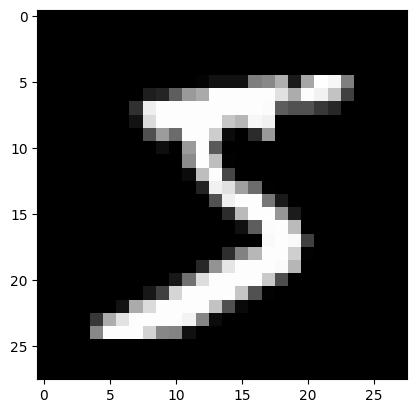

In [337]:
plt.imshow(train_dataset[0][0].numpy().transpose(1, 2, 0), cmap='gray')

In [338]:
autoencoder = Autoencoder()

In [339]:
autoencoder.eval()
autoencoder.training

False

In [466]:
class CVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.l1 = nn.Linear(794, 200)
        self.l21 = nn.Linear(200, 20)
        self.l22 = nn.Linear(200, 20)
        self.l3 = nn.Linear(30, 200)
        self.l4 = nn.Linear(200, 784)

    def encode(self, x, y):
        enc = torch.cat([x, y], axis=1)
        enc = F.relu(self.l1(enc))
        mu, logsigma = self.l21(enc), self.l22(enc)

        return mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std=torch.exp(logsigma)
            eps=torch.randn_like(std)
            return mu + eps * std

        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, y):
        dec = torch.cat([z, y], axis=1)
        dec = F.relu(self.l3(dec))
        reconstruction = F.sigmoid(self.l4(dec))

        return reconstruction

    def forward(self, x, y):
        # print(x.shape)
        # x = x.view(-1, 784)
        mu, logsigma = self.encode(x, y)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, y)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про CVAE и знаете, что лосс у CVAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x,y)||p(z|y)) + \log p_{\theta}(x|z,y)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [467]:
torch.tensor([1,2 ]).pow(2) + torch.tensor([1])

tensor([2, 5])

In [468]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * (1 + 2 * logsigma - mu.pow(2) - torch.exp(2 * logsigma)).sum()
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = F.binary_cross_entropy
    return loss(reconstruction, x, reduction='sum')

def wrapper(beta=1):
    def loss_vae(x, mu, logsigma, reconstruction, beta=beta):
        a, b = log_likelihood(x, reconstruction), KL_divergence(mu, logsigma)
        # print(f"Reconstruction loss: {a}")
        # print(f"{beta} * KL Divergence: {beta * b}")
        return log_likelihood(x, reconstruction) + beta * KL_divergence(mu, logsigma)
    return loss_vae

И обучим модель:

In [469]:
def train_epoch(model, train_loader, opt, critetion):
    train_loss = 0
    num_samples = 0

    model.train()
    for x_batch, y_batch in tqdm(train_loader):
        x_batch = x_batch.view(-1, 784).to(device)
        y_batch = torch.tensor([[int(digit==i) for i in range(10)] for digit in y_batch ]).to(device)
        mu, logsigma, reconstruction = model(x_batch, y_batch)
        loss = criterion(x_batch, mu, logsigma, reconstruction)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        num_samples += len(x_batch)

    train_loss /= num_samples
    return train_loss

def val_epoch(model, val_loader, critetion):
    val_loss = 0
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in tqdm(val_loader):
            x_batch = x_batch.view(-1, 784).to(device)
            y_batch = torch.tensor([[int(digit==i) for i in range(10)] for digit in y_batch ]).to(device)

            mu, logsigma, reconstruction = model(x_batch, y_batch)
            loss = criterion(x_batch, mu, logsigma, reconstruction)

            val_loss += loss.item()
            num_samples += len(x_batch)

    val_loss /= num_samples
    return val_loss

In [470]:
def learning_loop(model, train_loader, val_loader, opt, critetion, epochs=10, scheduler=None, history=None, draw_every=1):
    if history is None:
        history = {'train_loss': [], 'val_loss': [], 'lr': []}

    plt.subplots(1, 3)
    plt.grid(visible=True)

    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')

        train_loss = train_epoch(model, train_loader, opt, criterion)
        val_loss = val_epoch(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(opt.param_groups[0]['lr'])

        if scheduler is not None:
            try:
                scheduler.step()
            except:
                scheduler.step(val_loss)

        clear_output()
        print(f'train loss: {train_loss}')
        print(f'val loss: {val_loss}')
        plt.figure(figsize=(24, 6))
        plt.subplot(131)
        plt.plot(history['train_loss'], c='blue', label='Training Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Training Loss')
        plt.ylim(95, 117)

        plt.subplot(132)
        plt.plot(history['val_loss'], c='red', label='Validation Loss curve')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Loss')
        plt.ylim(95, 117)

        plt.subplot(133)
        plt.plot(history['lr'], c='green', label='Learning Rate curve')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        # plt.ylim(95, 117)

        if (epoch+1) % draw_every == 0:
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    break
            inds = np.random.choice(len(x_batch), 10, replace=False)
            x_batch = x_batch[inds].view(-1, 784).to(device)
            y_batch = torch.tensor([[int(digit==i) for i in range(10)] for digit in y_batch[inds] ]).to(device)
            _, _, reconstruction = model(x_batch, y_batch)

            fig, axes = plt.subplots(2, 10, figsize=(15, 5))

            for idx, (image, rec_image) in enumerate(zip(x_batch, reconstruction)):
                image = image.cpu().detach().numpy().reshape(28, 28, 1)
                rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

                plt.subplot(2, 10, idx+1)
                plt.imshow(image, cmap='gray')
                plt.axis('off')

                plt.subplot(2, 10, idx+11)
                plt.imshow(rec_image, cmap='gray')
                plt.axis('off')

        # plt.tight_layout()
        plt.show()



    return history

In [471]:
criterion = wrapper(beta=1)

autoencoder = CVAE().to(device)

opt = torch.optim.AdamW(autoencoder.parameters(), weight_decay=1e-2, lr=3e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=4)

In [472]:
for x_batch in test_loader:
    break

In [473]:
type(x_batch), x_batch[0].shape, x_batch[1].shape

(list, torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [474]:
len(test_loader)

79

train loss: 102.23300908203124
val loss: 95.68221650390625


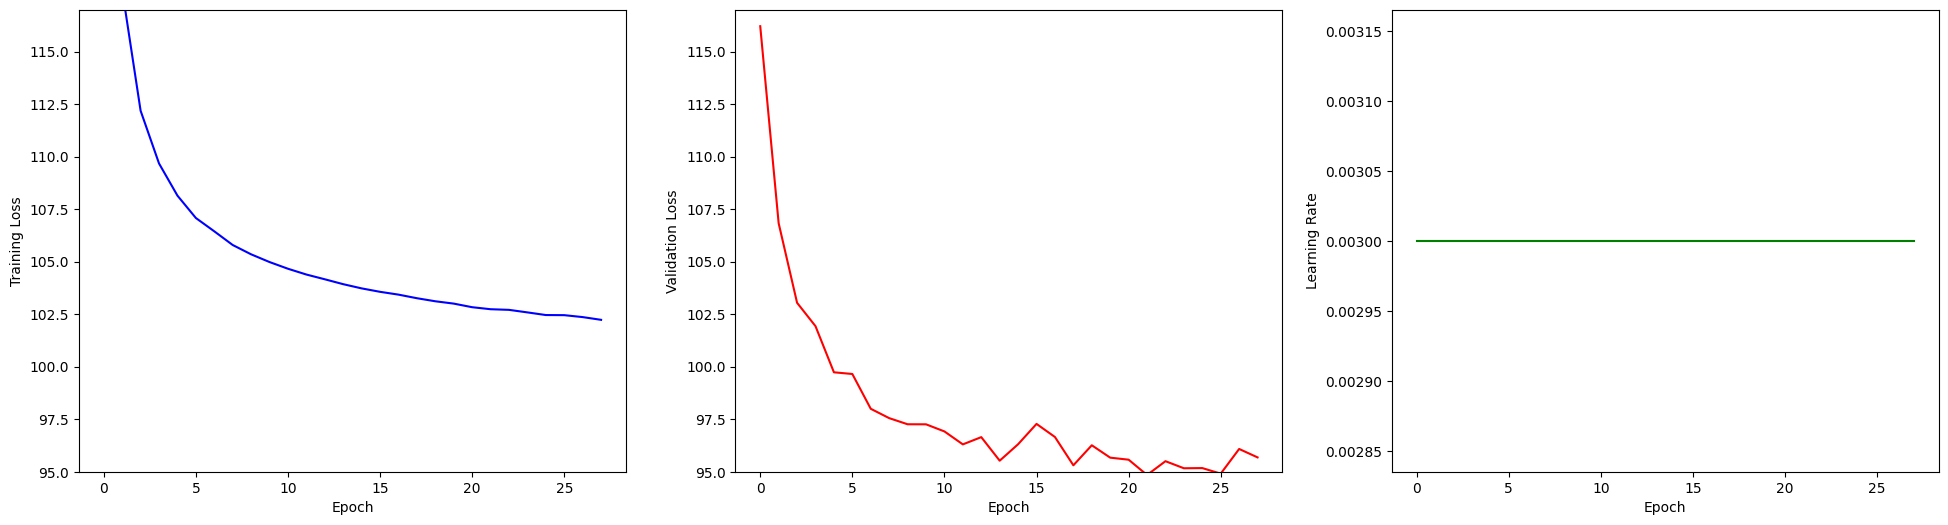

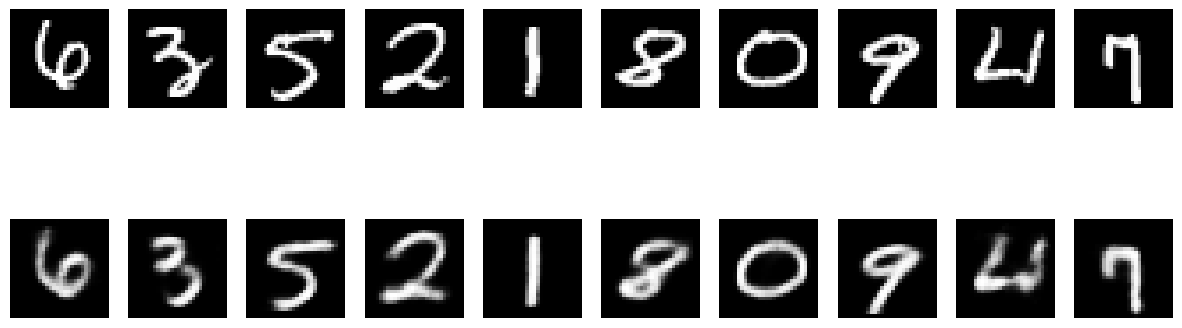

Epoch 29/50


  0%|          | 0/469 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [475]:
history=learning_loop(autoencoder, train_loader, test_loader, opt, criterion, epochs=50)

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

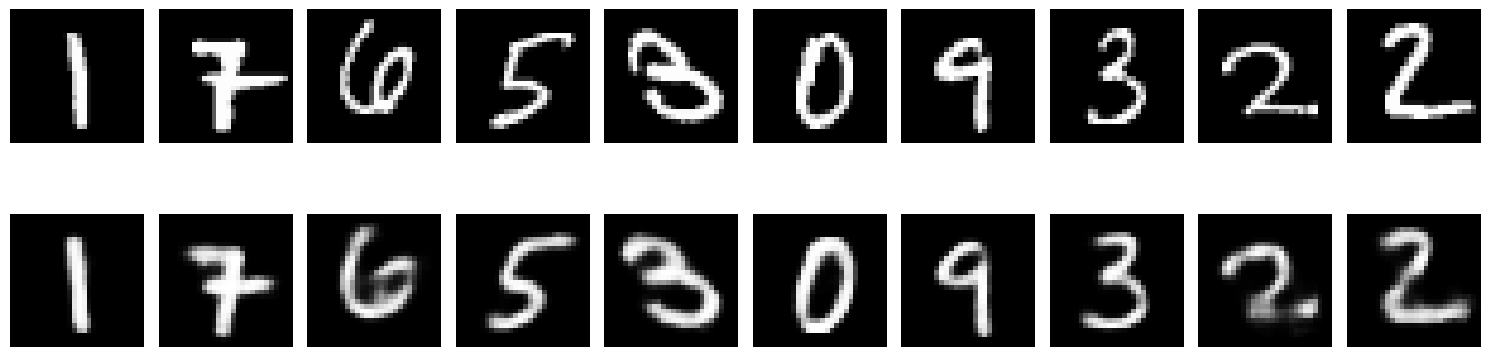

In [482]:
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        break
inds = np.random.choice(len(x_batch), 10, replace=False)
x_batch = x_batch[inds].view(-1, 784).to(device)
y_batch = torch.tensor([[int(digit==i) for i in range(10)] for digit in y_batch[inds] ]).to(device)
_, _, reconstruction = autoencoder(x_batch, y_batch)

fig, axes = plt.subplots(2, 10, figsize=(15, 5))

for idx, (image, rec_image) in enumerate(zip(x_batch, reconstruction)):
    image = image.cpu().detach().numpy().reshape(28, 28, 1)
    rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

    plt.subplot(2, 10, idx+1)
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 10, idx+11)
    plt.imshow(rec_image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [488]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
z = np.array([np.random.normal(0, 1, 20) for i in range(30)]).astype(np.float32)
labels = np.array([[int(i//3==j) for j in range(10)] for i in range(30)])
output = autoencoder.decode(torch.tensor(z).to(device), torch.tensor(labels).to(device))

In [489]:
output.shape

torch.Size([30, 784])

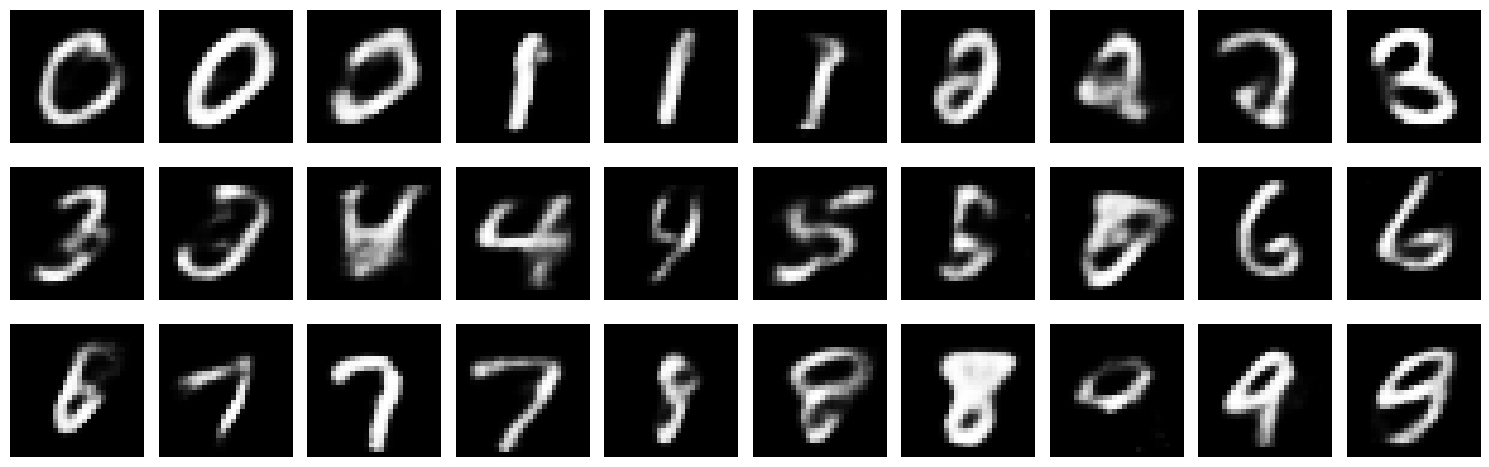

In [490]:
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for idx, rec_image in enumerate(output):
    rec_image = rec_image.cpu().detach().numpy().reshape(28, 28, 1)

    plt.subplot(3, 10, idx+1)
    plt.imshow(rec_image, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [495]:
dataset_latent_vectors, dataset_labels = zip(*[ (autoencoder.encode(x_batch.view(-1, 784).to(device), torch.tensor([[int(digit==i) for i in range(10)] for digit in y_batch ]).to(device))[0], y_batch) for x_batch, y_batch in train_loader])

In [496]:
dataset_labels = torch.cat(dataset_labels)
dataset_latent_vectors = torch.cat(dataset_latent_vectors, axis=0)

In [497]:
dataset_latent_vectors.shape

torch.Size([60000, 20])

In [498]:
import sklearn

In [499]:
compressed_vectors, compressed_labels = dataset_latent_vectors[:5000], dataset_labels[:5000]
compressed_vectors.shape

torch.Size([5000, 20])

In [500]:
tsne_vectors = sklearn.manifold.TSNE(n_components=2, perplexity=10, verbose=1).fit_transform(compressed_vectors.cpu().detach().numpy())

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.379s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.901390
[t-SNE] KL divergence after 250 iterations with early exaggeration: 100.561859
[t-SNE] KL divergence after 1000 iterations: 2.409774


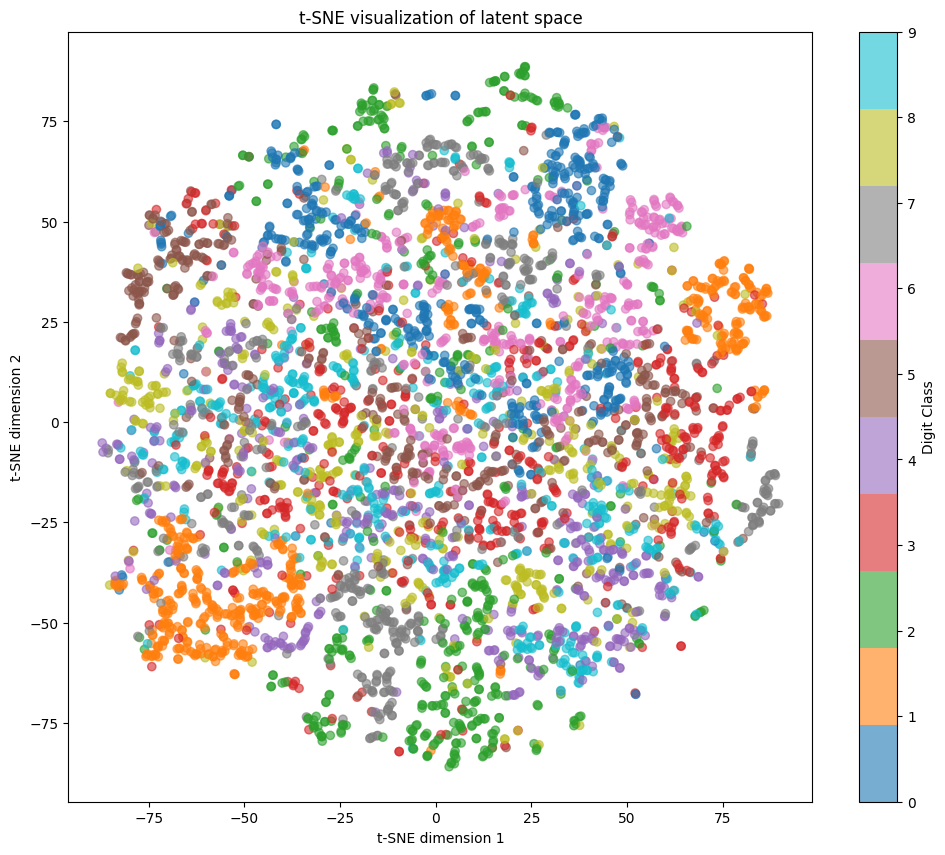

In [501]:
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_vectors[:, 0], tsne_vectors[:, 1], c=compressed_labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Class')
plt.title('t-SNE visualization of latent space')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

Что вы думаете о виде латентного представления?

__Congrats v2.0!__

На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class CVAE(nn.Module):
    def __init__(self):
        <определите архитектуры encoder и decoder
        помните, у encoder должны быть два "хвоста",
        т.е. encoder должен кодировать картинку в 2 переменные -- mu и logsigma>

    def encode(self, x, class_num):
        <реализуйте forward проход энкодера
        в качестве ваозвращаемых переменных -- mu, logsigma и класс картинки>

        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            <засемплируйте латентный вектор из нормального распределения с параметрами mu и sigma>
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, z, class_num):
        <реализуйте forward проход декодера
        в качестве возвращаемой переменной -- reconstruction>

        return reconstruction

    def forward(self, x):
        <используя encode и decode, реализуйте forward проход автоэнкодера
        в качестве ваозвращаемых переменных -- mu, logsigma и reconstruction>
        return mu, logsigma, reconstruction

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [ ]:
<тут нужно научиться сэмплировать из декодера цифры определенного класса>

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [ ]:
<ваш код получения латентных представлений, применения TSNE и визуализации>

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

# BONUS 1: Denoising

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудтье разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает щум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентныз представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>